## Predicting the sale price of bulldozers using machine learning
* The goal is to predict the future sale prices of bulldozers:
* Various python based Machine learning and DataScience libraries.Attempt to build a ML model for predicting future sale prices of bulldozers

steps: 1.problem definition 2.data 3.Evaluation 4.features_of data 5.Modeling 6.Experimentation

## Proble Definition
> How well can we predict the future sale price of bulldzores , given its characteristics and previous examples of how much similar bulldozers have been sold for.
## Data  
 * The data is downloaded from kaggle bluebook for bulldozers competition:
      https://www.kaggle.com/competitions/bluebook-for-bulldozers/data
*Train.csv is the training set, which contains data through the end of 2011.
* Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012 You make predictions on this set throughout the majority of the competition. Your score on this set is used to create the public leaderboard.
* Test.csv is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your score on the test set determines your final rank for the competition.                      

## Evaluation
* The evaluation metric for this competition is the RMSLE (root mean squared log error) between the actual and predicted auction prices.
   https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation
* Goal: Build a Machine Learning  model which minimises RMSLE.
## Features:
    * kaggle provides a data dictionary detailing all of the features:



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [58]:
df=pd.read_csv("TrainAndValid.csv",low_memory=False)
df.head(10)

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1139255,26500.0,1001274,4605,121,3.0,2004,508.0,Low,12/18/2008 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1139256,21000.0,772701,1937,121,3.0,1993,11540.0,High,8/26/2004 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
7,1139261,27000.0,902002,3539,121,3.0,2001,4883.0,High,11/17/2005 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1139272,21500.0,1036251,36003,121,3.0,2008,302.0,Low,8/27/2009 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
9,1139275,65000.0,1016474,3883,121,3.0,1000,20700.0,Medium,8/9/2007 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional


In [59]:
df.columns


Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [5]:
df.saledate[:100]

0     11/16/2006 0:00
1      3/26/2004 0:00
2      2/26/2004 0:00
3      5/19/2011 0:00
4      7/23/2009 0:00
           ...       
95    12/15/2005 0:00
96     1/29/2004 0:00
97     9/18/2008 0:00
98     11/3/2005 0:00
99      6/1/2006 0:00
Name: saledate, Length: 100, dtype: object

In [6]:
df.shape

(412698, 53)

In [7]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

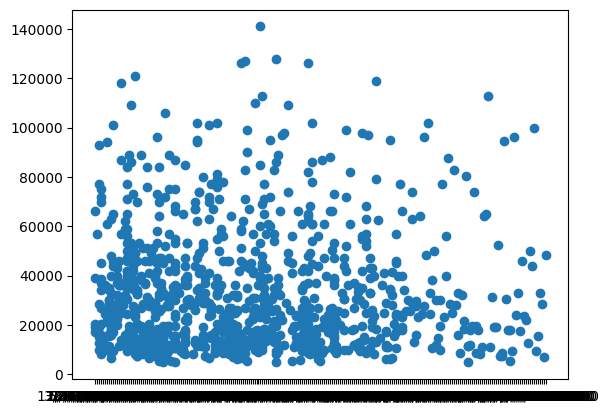

In [8]:
fig, ax= plt.subplots()
ax.scatter(df['saledate'][:1000], df['SalePrice'][:1000])

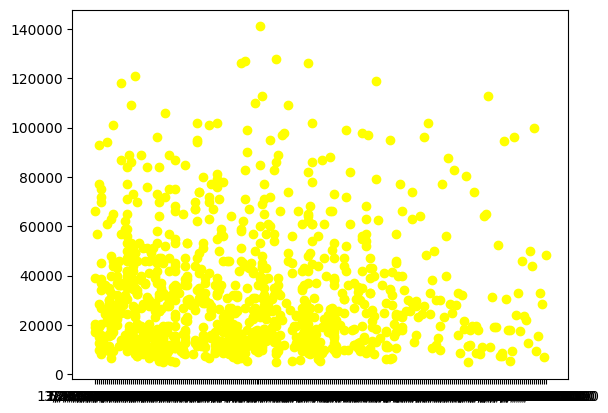

In [9]:
x=df.saledate[:1000]
y=df.SalePrice[:1000]
plt.scatter(x,y,color="yellow")
plt.show()

<Axes: ylabel='Frequency'>

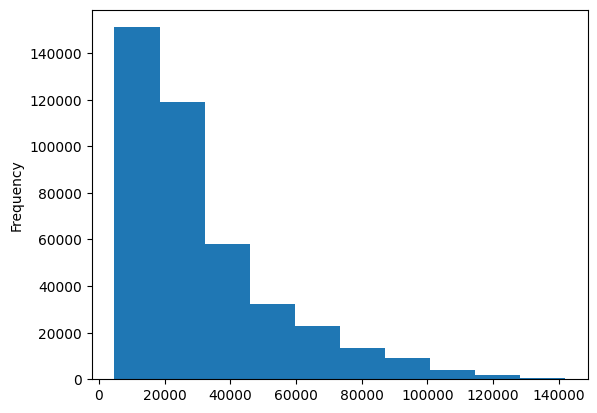

In [10]:
df.SalePrice.plot.hist()

<Axes: >

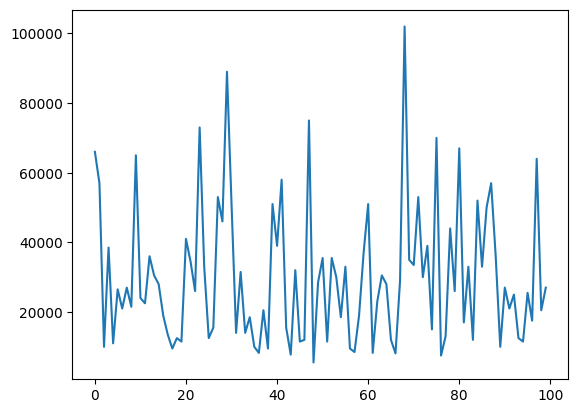

In [11]:
df.SalePrice[:100].plot()

### Parsing data
* when we work with time series data, we want to enrich the time and date components as much as possible.
* we can do that by telling pandas which of our columns has date init using the 'parse_dates' parameter  

In [65]:
## Import data again but this time parse dates
df=pd.read_csv("TrainAndValid.csv",low_memory=False,parse_dates=['saledate'])
df.saledate[:1000]

0     2006-11-16
1     2004-03-26
2     2004-02-26
3     2011-05-19
4     2009-07-23
         ...    
995   2009-07-16
996   2007-06-14
997   2005-09-22
998   2005-07-28
999   2011-06-16
Name: saledate, Length: 1000, dtype: datetime64[ns]

Text(0, 0.5, 'prices')

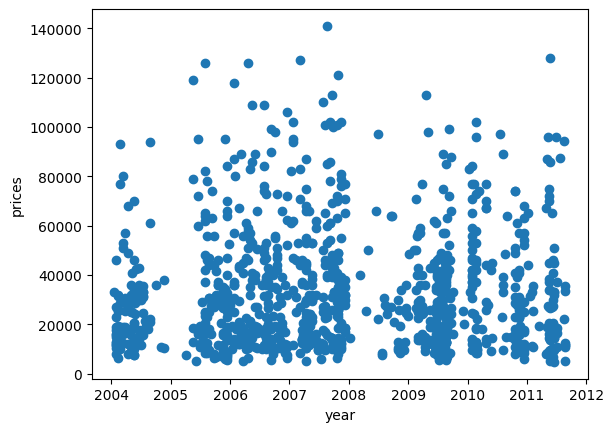

In [42]:
fig, ax= plt.subplots()
ax.scatter(df['saledate'][:1000], df['SalePrice'][:1000])
plt.xlabel("year")
plt.ylabel("prices")

In [26]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


### SORT DATAFRAME BY SALEDATE

when working with time series data it is good idea to sort it by date

In [66]:
df.sort_values(by=['saledate'],inplace=True,ascending=True)
df.saledate.head(30)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
144032   1989-01-31
54438    1989-01-31
144952   1989-01-31
205752   1989-01-31
28927    1989-01-31
86971    1989-01-31
67034    1989-01-31
87602    1989-01-31
53101    1989-01-31
205784   1989-01-31
Name: saledate, dtype: datetime64[ns]

### make a copy of original dataset 
* when we manipulate the data ,we still have original data.
    

In [67]:
df_org=df.copy()

In [15]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
205615,1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,1989-01-17,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
274835,1821514,14000.0,1194089,10150,132,99.0,1980,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
141296,1505138,50000.0,1473654,4139,132,99.0,1978,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
212552,1671174,16000.0,1327630,8591,132,99.0,1980,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
62755,1329056,22000.0,1336053,4089,132,99.0,1984,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,Lever,NaN,NaN


In [68]:
df_org.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


## Feature Engineering
### add datetime parameter for saledate column

In [69]:
df_org['saleyear']=df_org.saledate.dt.year
df_org['salemonth']=df_org.saledate.dt.month
df_org["saleday"]=df_org.saledate.dt.day
df_org["saleDayofWeek"]=df_org.saledate.dt.dayofweek
df_org["saleDayofYear"]=df_org.saledate.dt.dayofyear


In [70]:
df_org.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


# now we have enriched dataset our dataframe with date time features, now we can remove saledate column

In [71]:
df_org.drop("saledate",axis=1,inplace= True)
df_org.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [72]:
df_org.state.value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Iowa               1336
Montana            1336
Oklahoma           1326
Nebraska            866
West Virgi

In [21]:
df_org.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


## 5. Modelling

# we have done lot  EDA , lets start to do some model driven EDA 

## Lets build a Machine Learning Model


In [78]:
# np.random.seed(11)
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split

# model=RandomForestRegressor(n_jobs=-1,random_state=42)
# model.fit(df_org.drop("SalePrice",axis=1),df_org['SalePrice'])


ValueError: could not convert string to float: 'Low'

## Not worked due to data is combination of string objects and missing data

In [22]:
df_org.dtypes

SalesID                       int64
SalePrice                   float64
MachineID                     int64
ModelID                       int64
datasource                    int64
auctioneerID                float64
YearMade                      int64
MachineHoursCurrentMeter    float64
UsageBand                    object
fiModelDesc                  object
fiBaseModel                  object
fiSecondaryDesc              object
fiModelSeries                object
fiModelDescriptor            object
ProductSize                  object
fiProductClassDesc           object
state                        object
ProductGroup                 object
ProductGroupDesc             object
Drive_System                 object
Enclosure                    object
Forks                        object
Pad_Type                     object
Ride_Control                 object
Stick                        object
Transmission                 object
Turbocharged                 object
Blade_Extension             

In [73]:
## finds columns which contains strings datatypes,  .items() treats data as dictionary.
for key, value in df_org.items():
    if pd.api.types.is_string_dtype(value):
        print(key)


fiModelDesc
fiBaseModel
fiProductClassDesc
state
ProductGroup
ProductGroupDesc


In [74]:
## finds columns which contains objects datatypes,  .items() treats data as dictionary.
for key, value in df_org.items():
    if pd.api.types.is_object_dtype(value):
        print(key)


UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [75]:
for key,value in df_org.items():
    if not pd.api.types.is_numeric_dtype(value):
        print(key)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [76]:
## This will turn all non _numeric dataype to pandas category:
for key,value in df_org.items():
    if not pd.api.types.is_numeric_dtype(value):
        df_org[key]=value.astype("category").cat.as_ordered()

In [77]:
## This will turn all the string values into category values
for key, value in df_org.items():    
    if pd.api.types.is_string_dtype(value):
        df_org[key]=value.astype("category").cat.as_ordered()
         

In [78]:
## This will turn all the object values into category values
for key, value in df_org.items():    
    if pd.api.types.is_object_dtype(value):
        df_org[key]=value.astype("category").cat.as_ordered()
         

In [79]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [80]:
df_org.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

 Thanks to pandas categories, now we have way to accesss all of our data in the form of numbers
we now only have bunch of missing data...

In [81]:
# percentage of null values in each  column:
df_org.isna().sum()/len(df_org)*100

SalesID                      0.000000
SalePrice                    0.000000
MachineID                    0.000000
ModelID                      0.000000
datasource                   0.000000
auctioneerID                 4.879113
YearMade                     0.000000
MachineHoursCurrentMeter    64.258610
UsageBand                   82.149174
fiModelDesc                  0.000000
fiBaseModel                  0.000000
fiSecondaryDesc             34.099269
fiModelSeries               85.784520
fiModelDescriptor           81.871490
ProductSize                 52.485110
fiProductClassDesc           0.000000
state                        0.000000
ProductGroup                 0.000000
ProductGroupDesc             0.000000
Drive_System                74.051970
Enclosure                    0.080931
Forks                       52.092087
Pad_Type                    80.349796
Ride_Control                62.992794
Stick                       80.349796
Transmission                54.444412
Turbocharged

In [82]:
#### save preprocessed data 
# export currents datafarame

df_org.to_csv("data.csv",index=False)

In [62]:
df_org.to_csv("data1.csv",index=False)

In [ ]:
data1=pd.read_csv("data1.csv",low_memory=False)


In [83]:
data=pd.read_csv("data.csv",low_memory=False)

In [84]:
data.head().T


,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [86]:
data['SalePrice'].head(5)

0     9500.0
1    14000.0
2    50000.0
3    16000.0
4    22000.0
Name: SalePrice, dtype: float64

### Fill missing values
# fill numerical missing values

In [87]:
# Find numerical columns
for key,value in data.items():
    if pd.api.types.is_numeric_dtype(value):
        print(key)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleyear
salemonth
saleday
saleDayofWeek
saleDayofYear


In [88]:
## check which numeric columns have null values:
for key,value in data.items():
    if pd.api.types.is_numeric_dtype(value):
        if pd.isnull(value).sum():
            print(key)
            
        
        

auctioneerID
MachineHoursCurrentMeter


In [89]:
## fill numeric missing values with median,median is more robust than mean ,its is less sensitive to outliers.

for key,value in data.items():
    if pd.api.types.is_numeric_dtype(value):
        if pd.isnull(value).sum():
            data[key+'_is_missing']=pd.isnull(value)
            data[key]=value.fillna(value.median())

In [90]:
# check if any missing value remained
for key,value in data.items():
    if pd.api.types.is_numeric_dtype(value):
        if pd.isnull(value).sum():
            print(key)
            

In [91]:
# No 

In [92]:
data.isna().sum()

SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

## Fill missing values in categorial columns:


In [93]:
# check for columns which are not numerical
for key, value in data.items():
    if not pd.api.types.is_numeric_dtype(value):
        if pd.isnull(value).sum():
            print(key)
      
        

UsageBand
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [95]:
# Turn categorial values into numerical and fill missing values
for key,value in data.items():
    if not pd.api.types.is_numeric_dtype(value):
        # turn into numeric and add+1;
        data[key]=pd.Categorical(value).codes+1  

In [96]:
data["state"].astype("category").cat.categories

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53],
      dtype='int8')

In [64]:
df["state"].astype("category").cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [97]:
data.isna().sum()

SalesID                                0
SalePrice                              0
MachineID                              0
ModelID                                0
datasource                             0
auctioneerID                           0
YearMade                               0
MachineHoursCurrentMeter               0
UsageBand                              0
fiModelDesc                            0
fiBaseModel                            0
fiSecondaryDesc                        0
fiModelSeries                          0
fiModelDescriptor                      0
ProductSize                            0
fiProductClassDesc                     0
state                                  0
ProductGroup                           0
ProductGroupDesc                       0
Drive_System                           0
Enclosure                              0
Forks                                  0
Pad_Type                               0
Ride_Control                           0
Stick           


# Now we have all the data numeric and no missing values.we should be able to build a machine learning model.


In [25]:
data.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Travel_Controls,Differential_Type,Steering_Controls,saleyear,salemonth,saleday,saleDayofWeek,saleDayofYear,auctioneerID_is_missing,MachineHoursCurrentMeter_is_missing
0,1646770,9500.0,1126363,8434,132,18.0,1974,0.0,0,4593,...,6,0,0,1989,1,17,1,17,False,True
1,1821514,14000.0,1194089,10150,132,99.0,1980,0.0,0,1820,...,0,4,2,1989,1,31,1,31,False,True
2,1505138,50000.0,1473654,4139,132,99.0,1978,0.0,0,2348,...,6,0,0,1989,1,31,1,31,False,True
3,1671174,16000.0,1327630,8591,132,99.0,1980,0.0,0,1819,...,0,4,2,1989,1,31,1,31,False,True
4,1329056,22000.0,1336053,4089,132,99.0,1984,0.0,0,2119,...,5,0,0,1989,1,31,1,31,False,True


In [26]:
data.to_csv("data2.csv",index=False)

In [108]:
data2=pd.read_csv("data2.csv")
data2.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Travel_Controls,Differential_Type,Steering_Controls,saleyear,salemonth,saleday,saleDayofWeek,saleDayofYear,auctioneerID_is_missing,MachineHoursCurrentMeter_is_missing
0,1646770,9500.0,1126363,8434,132,18.0,1974,0.0,0,4593,...,6,0,0,1989,1,17,1,17,False,True
1,1821514,14000.0,1194089,10150,132,99.0,1980,0.0,0,1820,...,0,4,2,1989,1,31,1,31,False,True
2,1505138,50000.0,1473654,4139,132,99.0,1978,0.0,0,2348,...,6,0,0,1989,1,31,1,31,False,True
3,1671174,16000.0,1327630,8591,132,99.0,1980,0.0,0,1819,...,0,4,2,1989,1,31,1,31,False,True
4,1329056,22000.0,1336053,4089,132,99.0,1984,0.0,0,2119,...,5,0,0,1989,1,31,1,31,False,True


In [104]:
## select the model and fit to data
from sklearn.ensemble import RandomForestRegressor
reg_model=RandomForestRegressor(n_jobs=-1,
                               random_state=42)
reg_model.fit(data.drop("SalePrice",axis=1),data['SalePrice'])

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
reg_model.score(data.drop("SalePrice",axis=1),data['SalePrice'])

0.9875569693359224

# ** Question: **
# why doesn't above metrics is reliable:
## because we trained and tested on same data i.e. train and valid csv


In [98]:
# split data  into training and validation set:
df_val=data[data.saleyear==2012]
df_train=data[data.saleyear!=2012]
len(df_val),len(df_train)


(11573, 401125)

In [99]:
## split data into x and y
x_train,y_train=df_train.drop("SalePrice",axis=1),df_train.SalePrice
x_valid,y_valid=df_val.drop("SalePrice",axis=1),df_val.SalePrice

x_train.shape,y_train.shape,x_valid.shape,y_valid.shape

((401125, 58), (401125,), (11573, 58), (11573,))

## Building and Evaluation metrix:


In [100]:
# create Evaluation function:RMSLE
from sklearn.metrics import mean_squared_log_error,mean_absolute_error,r2_score
def rmsle(y_test,y_preds):
    # calculate root mean squared log error between predicted and true values
    return np.sqrt(mean_squared_log_error(y_test,y_preds))
# create function to evaluate model on a few different levels
def show_scores(model):
    train_preds=model.predict(x_train)
    val_preds=model.predict(x_valid)
    scores={"Training MAE":mean_absolute_error(y_train,train_preds),
           "valid MAE":mean_absolute_error(y_valid,val_preds),
           "Training RMSLE:":rmsle(y_train,train_preds),
           "valid RMSLE":rmsle(y_valid, val_preds),
           "training r2":r2_score(y_train,train_preds),
           "val r2":r2_score(y_valid,val_preds)}
    return scores
    
    

Testing our model on a subset: our data is very long 4 lakh+ rows , taking a lot time. 



In [101]:
# change max_samples value
from sklearn.ensemble import RandomForestRegressor
# model=RandomForestRegressor(n_jobs=-1,random_state=42,max_samples=10000)
# model.fit(x_train,y_train)


In [46]:
# model.score(x_valid,y_valid)

0.8317030309906168

In [51]:
# show_scores(model)

In [47]:
%%time
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
r_grid={"n_estimators":np.arange(10,100,10),
       "max_depth":[None,3,5,10],
    "min_samples_split":np.arange(2,20,2),
        "min_samples_leaf":np.arange(1,20,2),
        "max_features":[0.5,1,'sqrt','log2'],
        "max_samples":[10000]}
model_1=RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,random_state=42),
                          param_distributions=r_grid,
                          n_iter=2,
                          cv=5,
                          verbose=True)

model_1.fit(x_train,y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
CPU times: total: 2min 1s
Wall time: 47 s


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [10000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,n_iter,2
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [48]:
# Find best parameters:
model_1.best_params_

{'n_estimators': np.int64(80),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': None}

In [49]:
# Increased due to we tried only 2 iters. u can upto 100 if youn have sufficient time
show_scores(model_1)

{'Training MAE': 6888.263837935772,
 'valid MAE': 8256.76798115587,
 'Training RMSLE:': np.float64(0.3073936639111722),
 'valid RMSLE': np.float64(0.3323598283926132),
 'training r2': 0.792900242751886,
 'val r2': 0.7792949073976925}

## Train a model with best hyperparameter 
'Note': These were found after 100 iterations 

In [104]:
ideal_model=RandomForestRegressor(n_estimators=40,
                                 min_samples_split=14,
                                 min_samples_leaf=1,
                                 max_features=0.5,
                                 n_jobs=-1,
                                 max_samples=None,
                                 random_state=42)
## fit the model
ideal_model.fit(x_train,y_train)
                                  

,n_estimators,40
,criterion,'squared_error'
,max_depth,None
,min_samples_split,14
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [106]:
ideal_model.score(x_valid,y_valid)

0.8812432673318574

In [107]:
# scores for ideal model trained on all data
show_scores(ideal_model)

{'Training MAE': 2953.298272047334,
 'valid MAE': 5974.138229142348,
 'Training RMSLE:': np.float64(0.1447050760247942),
 'valid RMSLE': np.float64(0.2468749202730781),
 'training r2': 0.9588470253928829,
 'val r2': 0.8812432673318574}

* scores of model trained on 10000 lines of data:
* {'Training MAE': 5563.967707472733,
* 'valid MAE': 7179.196131513004,
* 'Training RMSLE:': np.float64(0.2578543924858488),
* 'valid RMSLE': np.float64(0.2934220379244748),
* 'training r2': 0.8605293366611149,
* 'val r2': 0.8317030309906168}

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import joblib



joblib.dump(X.columns.tolist(), "columns.pkl")

# Use final processed dataframe
df_sample = data.sample(50000, random_state=42)

X = df_sample.drop("SalePrice", axis=1)
y = df_sample["SalePrice"]

# Identify columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numerical_cols)
])

# Model
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=50))
])

# Train
pipeline.fit(X, y)

# Save
joblib.dump(pipeline, "Bulldozer_model.pkl")

print("Pipeline model saved successfully!")

Pipeline model saved successfully!


In [ ]:
# import pickle

# # Save model
# pickle.dump(model, open("model.pkl", "wb"))

# # Save column structure
# pickle.dump(X_train.columns, open("columns.pkl", "wb"))

# Make Predictions on Test Data

In [54]:
# Import test.csv
test=pd.read_csv("Test.csv",low_memory=False,parse_dates=['saledate'])
test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


In [55]:
# make predictions on test dataset
# test_preds=ideal_model.predict(test)

In [55]:
test.isna().sum()

SalesID                         0
MachineID                       0
ModelID                         0
datasource                      0
auctioneerID                    0
YearMade                        0
MachineHoursCurrentMeter    10328
UsageBand                   10623
saledate                        0
fiModelDesc                     0
fiBaseModel                     0
fiSecondaryDesc              3975
fiModelSeries               10451
fiModelDescriptor            9433
ProductSize                  6409
fiProductClassDesc              0
state                           0
ProductGroup                    0
ProductGroupDesc                0
Drive_System                 9698
Enclosure                       2
Forks                        6149
Pad_Type                    10349
Ride_Control                 8216
Stick                       10349
Transmission                 7639
Turbocharged                10349
Blade_Extension             11806
Blade_Width                 11806
Enclosure_Type

In [56]:
## preprocessing data (getting dataset in the format as our training dataset)
def preprocess(df):
    df.sort_values(by=['saledate'],inplace=True,ascending=True)
    df['saleyear']=df.saledate.dt.year
    df['salemonth']=df.saledate.dt.month
    df["saleday"]=df.saledate.dt.day
    df["saleDayofWeek"]=df.saledate.dt.dayofweek
    df["saleDayofYear"]=df.saledate.dt.dayofyear
    df.drop('saledate',axis=1,inplace=True)
    # convert all non numeric rows to categories:
    for key,value in df.items():
        if not pd.api.types.is_numeric_dtype(value):
            df[key]=value.astype("category").cat.as_ordered
    # fill all numeric rows with median
    for key,value in df.items():
        if  pd.api.types.is_numeric_dtype(value):
            if pd.isnull(value).sum():
                df[key]=value.fillna(value.median())
    # convert categories into numbers and fill using cat codes:            
    for key,value in df.items():
        if not pd.api.types.is_numeric_dtype(value):
            df[key]=pd.Categorical(value).codes+1           
  
    return(df)             
                

In [57]:
# process the test data
test_data=preprocess(test)
test_data.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleyear,salemonth,saleday,saleDayofWeek,saleDayofYear
1408,4317459,2295526,8132,172,1,1998,4359.0,1,1,1,...,1,1,1,1,1,2012,5,1,1,122
1023,4249784,1745722,3178,172,1,1995,4489.0,1,1,1,...,1,1,1,1,1,2012,5,1,1,122
1728,4392603,2283116,18111,172,1,2004,2126.0,1,1,1,...,1,1,1,1,1,2012,5,1,1,122
1167,4274831,2288988,3783,172,1,2001,9115.0,1,1,1,...,1,1,1,1,1,2012,5,1,1,122
1594,4362801,2300591,16490,172,1,2006,885.0,1,1,1,...,1,1,1,1,1,2012,5,1,1,122


In [58]:
# make predictions on updated test data
test_preds=ideal_model.predict(test_data)
test_preds.head()

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- MachineHoursCurrentMeter_is_missing
- auctioneerID_is_missing


In [90]:
x_train.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Travel_Controls,Differential_Type,Steering_Controls,saleyear,salemonth,saleday,saleDayofWeek,saleDayofYear,auctioneerID_is_missing,MachineHoursCurrentMeter_is_missing
0,1646770,1126363,8434,132,18.0,1974,0.0,0,4593,1744,...,6,0,0,1989,1,17,1,17,False,True
1,1821514,1194089,10150,132,99.0,1980,0.0,0,1820,559,...,0,4,2,1989,1,31,1,31,False,True
2,1505138,1473654,4139,132,99.0,1978,0.0,0,2348,713,...,6,0,0,1989,1,31,1,31,False,True
3,1671174,1327630,8591,132,99.0,1980,0.0,0,1819,558,...,0,4,2,1989,1,31,1,31,False,True
4,1329056,1336053,4089,132,99.0,1984,0.0,0,2119,683,...,5,0,0,1989,1,31,1,31,False,True


In [59]:
# we can find how the columns  differe using sets
set(x_train.columns)-set(test_data.columns)

{'MachineHoursCurrentMeter_is_missing', 'auctioneerID_is_missing'}

In [60]:
# manually adjust test_data to have this columns :
test_data["auctioneerID_is_missing"]=False
test_data["MachineHoursCurrentMeter_is_missing"]=False
test_data.head()


,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Travel_Controls,Differential_Type,Steering_Controls,saleyear,salemonth,saleday,saleDayofWeek,saleDayofYear,auctioneerID_is_missing,MachineHoursCurrentMeter_is_missing
1408,4317459,2295526,8132,172,1,1998,4359.0,1,1,1,...,1,1,1,2012,5,1,1,122,False,False
1023,4249784,1745722,3178,172,1,1995,4489.0,1,1,1,...,1,1,1,2012,5,1,1,122,False,False
1728,4392603,2283116,18111,172,1,2004,2126.0,1,1,1,...,1,1,1,2012,5,1,1,122,False,False
1167,4274831,2288988,3783,172,1,2001,9115.0,1,1,1,...,1,1,1,2012,5,1,1,122,False,False
1594,4362801,2300591,16490,172,1,2006,885.0,1,1,1,...,1,1,1,2012,5,1,1,122,False,False


In [61]:
# make predictions on updated test data
test_preds=ideal_model.predict(test_data)
len(test_preds)

12457

In [98]:
# format predictions into same format kaggle is asking for:
df_preds=pd.DataFrame()
df_preds['SalesID']=test_data['SalesID']
df_preds['SalesPrice']=test_preds
df_preds

,SalesID,SalesPrice
1408,4317459,21701.576446
1023,4249784,17601.292234
1728,4392603,29399.541869
1167,4274831,25058.798128
1594,4362801,31853.629285
...,...,...
9941,6620191,31235.106025
9936,6620142,33960.383135
11620,6635116,26589.159745
9995,6621460,31007.877206


In [99]:
# export predictions daata to csv:
df_preds.to_csv("test_predictions.csv",index=False)

# Feature Importance

 Feature importance seeks to figure out which different attributes helps in predicting the expected target variables.

In [62]:
# Find feature importance 
ideal_model.feature_importances_*100



array([ 3.15462122,  1.89103408,  4.59413762,  0.19695777,  0.33207781,
       18.99306389,  0.33259761,  0.11236791,  4.40096448,  3.69166368,
        7.36547947,  0.59236367,  2.79195922, 14.59326524,  5.1029754 ,
        0.6040316 ,  0.67312667,  0.6847426 ,  0.25280533,  8.05045973,
        0.06152625,  0.04276269,  0.10613778,  0.09189355,  0.13857142,
        0.03169661,  0.04589379,  0.2736534 ,  0.63039502,  0.277547  ,
        1.58082918,  0.49756389,  0.54378124,  0.4447634 ,  0.50076561,
        0.77083055,  0.12991094,  2.47975572,  1.10909237,  0.70833532,
        0.2618839 ,  0.16590088,  0.12063237,  0.06244944,  0.05632202,
        0.08342859,  0.07251626,  0.2810233 ,  0.15075008,  0.03029558,
        0.04731373,  7.37340278,  0.37936477,  0.57290831,  0.29457403,
        0.98751434,  0.02676104,  0.15655781])

In [104]:
x_train.columns

Index(['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID',
       'YearMade', 'MachineHoursCurrentMeter', 'UsageBand', 'fiModelDesc',
       'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor',
       'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup',
       'ProductGroupDesc', 'Drive_System', 'Enclosure', 'Forks', 'Pad_Type',
       'Ride_Control', 'Stick', 'Transmission', 'Turbocharged',
       'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower',
       'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control',
       'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks',
       'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width',
       'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type',
       'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls',
       'Differential_Type', 'Steering_Controls', 'saleyear', 'salemonth',
       'saleday', 'saleDayofWeek', 'saleDayofYear', 'auctioneerID_is_missing'

In [63]:

for feature, importance in zip(x_train.columns, ideal_model.feature_importances_ * 100):
    print(f"{feature}: {importance:.2f}%")


SalesID: 3.15%
MachineID: 1.89%
ModelID: 4.59%
datasource: 0.20%
auctioneerID: 0.33%
YearMade: 18.99%
MachineHoursCurrentMeter: 0.33%
UsageBand: 0.11%
fiModelDesc: 4.40%
fiBaseModel: 3.69%
fiSecondaryDesc: 7.37%
fiModelSeries: 0.59%
fiModelDescriptor: 2.79%
ProductSize: 14.59%
fiProductClassDesc: 5.10%
state: 0.60%
ProductGroup: 0.67%
ProductGroupDesc: 0.68%
Drive_System: 0.25%
Enclosure: 8.05%
Forks: 0.06%
Pad_Type: 0.04%
Ride_Control: 0.11%
Stick: 0.09%
Transmission: 0.14%
Turbocharged: 0.03%
Blade_Extension: 0.05%
Blade_Width: 0.27%
Enclosure_Type: 0.63%
Engine_Horsepower: 0.28%
Hydraulics: 1.58%
Pushblock: 0.50%
Ripper: 0.54%
Scarifier: 0.44%
Tip_Control: 0.50%
Tire_Size: 0.77%
Coupler: 0.13%
Coupler_System: 2.48%
Grouser_Tracks: 1.11%
Hydraulics_Flow: 0.71%
Track_Type: 0.26%
Undercarriage_Pad_Width: 0.17%
Stick_Length: 0.12%
Thumb: 0.06%
Pattern_Changer: 0.06%
Grouser_Type: 0.08%
Backhoe_Mounting: 0.07%
Blade_Type: 0.28%
Travel_Controls: 0.15%
Differential_Type: 0.03%
Steering_Con

Thus we have developed a machine learning model for predicting the future  prices of bulldozers on given fetures of data  with the accuracy score of nearly 90 %.
Before hyperparameter tunning , model shown the score of 83 %, tunning has increased the accuracy of 6 to 7 % . 

Saving ideal_model

In [57]:
import joblib
from joblib import dump 
joblib.dump(ideal_model,"Bulldozers Future_Price_Predictor.pkl")

['Bulldozers Future_Price_Predictor.pkl']